In [1]:
!pip install statsmodels

# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Load Dataset

In [3]:
df = pd.read_csv("Silver_daily_ohlcv_2000_2025.csv")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df.set_index('Date', inplace=True)

# Sort data
df = df.sort_index()

# Select Target Column (Close Price)

In [5]:
data = df['Close']

# Visualize Data

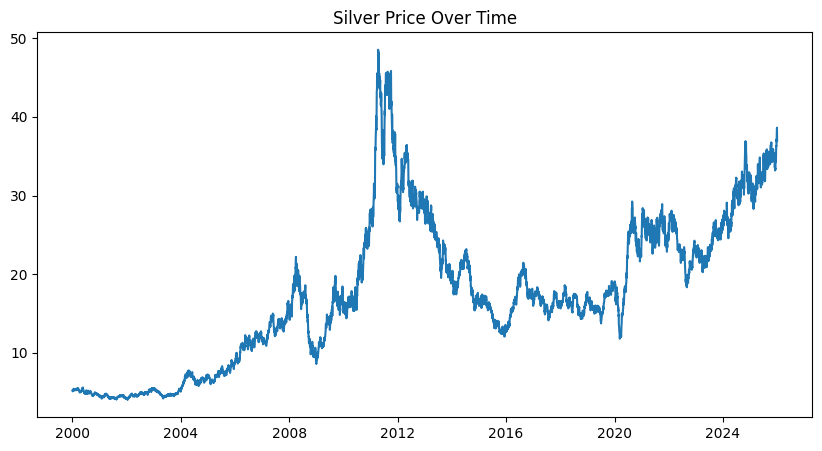

In [7]:
plt.figure(figsize=(10,5))
plt.plot(data)
plt.title("Silver Price Over Time")
plt.show()

# Train-Test Split

In [9]:
train = data[:'2022']
test = data['2023':]

# Build ARIMA Model 

In [34]:
model = ARIMA(data, order=(2,1,2))
model_fit = model.fit()

predictions = model_fit.forecast(steps=30)
print(predictions)

C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


2026-01-01    36.975545
2026-01-02    36.983904
2026-01-05    36.990395
2026-01-06    36.994341
2026-01-07    36.995340
2026-01-08    36.993307
2026-01-09    36.988481
2026-01-12    36.981394
2026-01-13    36.972818
2026-01-14    36.963676
2026-01-15    36.954944
2026-01-16    36.947550
2026-01-19    36.942270
2026-01-20    36.939651
2026-01-21    36.939952
2026-01-22    36.943121
2026-01-23    36.948799
2026-01-26    36.956365
2026-01-27    36.964998
2026-01-28    36.973774
2026-01-29    36.981757
2026-01-30    36.988104
2026-02-02    36.992149
2026-02-03    36.993481
2026-02-04    36.991976
2026-02-05    36.987815
2026-02-06    36.981460
2026-02-09    36.973604
2026-02-10    36.965092
2026-02-11    36.956836
Freq: B, Name: predicted_mean, dtype: float64


# Make Predictions

In [36]:
predictions = model_fit.forecast(steps=len(test))

# Plot Results

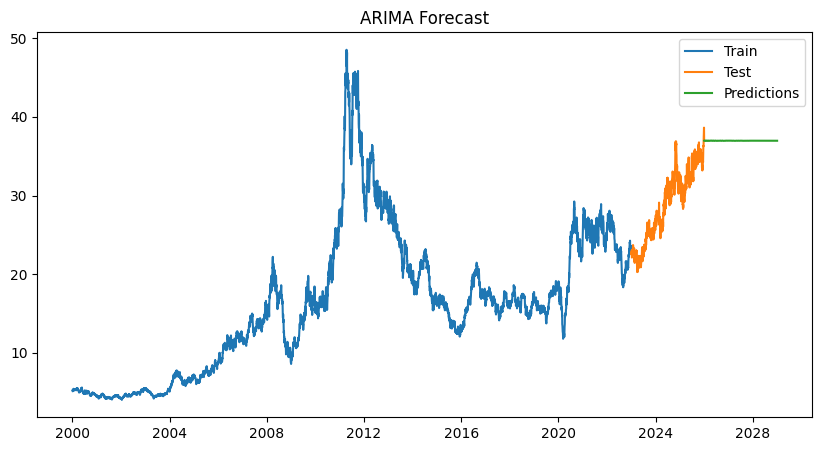

In [38]:
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(predictions, label='Predictions')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

# Check Accuracy

In [40]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 9.315212889428967


In [42]:
pred_df = pd.DataFrame({
    'Date': test.index,
    'Predicted': predictions
})

pred_df.reset_index(drop=True, inplace=True)

In [44]:
final_df = df.reset_index()

final_df = final_df.merge(
    pred_df,
    on='Date',
    how='left'
)

In [46]:
print(final_df.columns)
print(final_df.tail())

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'VWAP',
       'Returns_Pct', 'Log_Returns', 'Dollar_Change', 'Intraday_Range',
       'Intraday_Range_Pct', 'Predicted'],
      dtype='object')
           Date     Open     High      Low    Close  Adj_Close  Volume  \
6778 2025-12-25  37.4688  37.5215  37.4688  37.4841    37.4841   68508   
6779 2025-12-26  37.7006  37.8512  37.7006  37.7450    37.7450   79159   
6780 2025-12-29  38.5685  38.6695  38.5685  38.6309    38.6309  152138   
6781 2025-12-30  37.3861  37.3861  37.0511  37.1281    37.1281  126638   
6782 2025-12-31  37.1611  37.2931  36.8399  36.9662    36.9662   50484   

         VWAP  Returns_Pct  Log_Returns  Dollar_Change  Intraday_Range  \
6778  37.4915       1.6844     0.016704         0.6209          0.0527   
6779  37.7656       0.6962     0.006938         0.2610          0.1506   
6780  38.6230       2.3469     0.023198         0.8858          0.1010   
6781  37.1884      -3.8901    -0.039678     

In [48]:
final_df.to_csv("silver_daily_ohlcv_2000_2025.csv", index=False)

In [52]:
final_df

,Date,Open,High,Low,Close,Adj_Close,Volume,VWAP,Returns_Pct,Log_Returns,Dollar_Change,Intraday_Range,Intraday_Range_Pct,Predicted
0,2000-01-03,5.1962,5.1962,5.1884,5.1910,5.1910,36286,5.1919,-0.1729,-0.001731,-0.0090,0.0078,0.1511,NaN
1,2000-01-04,5.1084,5.1084,5.0848,5.0980,5.0980,35819,5.0971,-1.7916,-0.018079,-0.0930,0.0236,0.4649,NaN
2,2000-01-05,5.1388,5.1464,5.1388,5.1412,5.1412,38844,5.1421,0.8480,0.008444,0.0432,0.0076,0.1472,NaN
3,2000-01-06,5.2123,5.2291,5.2123,5.2239,5.2239,24445,5.2218,1.6076,0.015948,0.0826,0.0168,0.3225,NaN
4,2000-01-07,5.2766,5.2832,5.2766,5.2779,5.2779,40020,5.2792,1.0344,0.010291,0.0540,0.0066,0.1251,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6778,2025-12-25,37.4688,37.5215,37.4688,37.4841,37.4841,68508,37.4915,1.6844,0.016704,0.6209,0.0527,0.1406,36.965289
6779,2025-12-26,37.7006,37.8512,37.7006,37.7450,37.7450,79159,37.7656,0.6962,0.006938,0.2610,0.1506,0.3994,36.965191
6780,2025-12-29,38.5685,38.6695,38.5685,38.6309,38.6309,152138,38.6230,2.3469,0.023198,0.8858,0.1010,0.2618,36.965277
6781,2025-12-30,37.3861,37.3861,37.0511,37.1281,37.1281,126638,37.1884,-3.8901,-0.039678,-1.5028,0.3350,0.9042,36.965537


In [31]:
print(df.columns)


Index(['Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'VWAP',
       'Returns_Pct', 'Log_Returns', 'Dollar_Change', 'Intraday_Range',
       'Intraday_Range_Pct'],
      dtype='object')
